In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

DATA_PATH = "/content/drive/MyDrive/FactLens_Group9/data"

for item in os.listdir(DATA_PATH):
    print(item)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/FactLens_Group9/data'

In [ ]:
import pandas as pd

df_fake = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/Fake.csv")
df_real = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/True.csv")

df_fake["label"] = "FAKE"
df_real["label"] = "REAL"

df = pd.concat([df_fake, df_real], ignore_index=True)

print("Dataset loaded successfully")
print(f"Total articles: {len(df)}")

Dataset loaded successfully
Total articles: 44898


In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

First 5 rows:


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",FAKE
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",FAKE
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",FAKE
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",FAKE
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",FAKE


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


Article count per label:
label
FAKE    23481
REAL    21417
Name: count, dtype: int64


/tmp/ipykernel_427/3637211806.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette=["#E74C3C", "#2ECC71"])


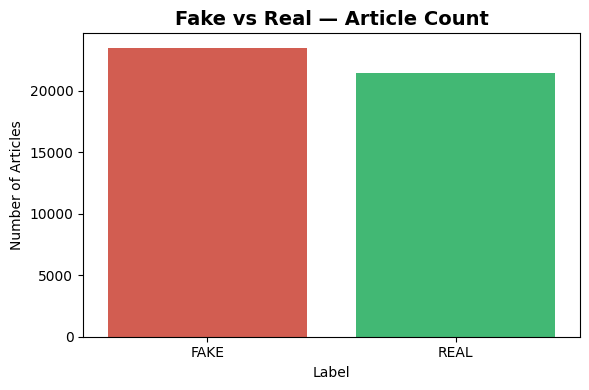

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Article count per label:")
print(df["label"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df, palette=["#E74C3C", "#2ECC71"])
plt.title("Fake vs Real — Article Count", fontsize=14, fontweight="bold")
plt.xlabel("Label")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

Article length statistics:
         count    mean     std  min     25%     50%     75%      max
label                                                               
FAKE   23481.0  2547.0  2533.0  1.0  1433.0  2166.0  3032.0  51794.0
REAL   21417.0  2383.0  1685.0  1.0   914.0  2222.0  3237.0  29781.0


/tmp/ipykernel_427/2671583551.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="text_length", data=df, palette=["#E74C3C", "#2ECC71"])


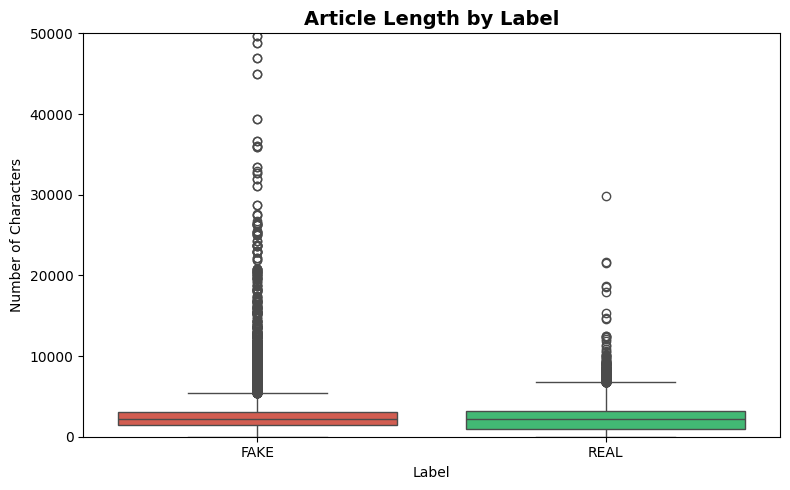

In [ ]:
df["text_length"] = df["text"].apply(len)

print("Article length statistics:")
print(df.groupby("label")["text_length"].describe().round(0))

plt.figure(figsize=(8, 5))
sns.boxplot(x="label", y="text_length", data=df, palette=["#E74C3C", "#2ECC71"])
plt.title("Article Length by Label", fontsize=14, fontweight="bold")
plt.xlabel("Label")
plt.ylabel("Number of Characters")
plt.ylim(0, 50000)
plt.tight_layout()
plt.show()

Word count statistics:
         count   mean    std  min    25%    50%    75%     max
label                                                         
FAKE   23481.0  423.0  408.0  0.0  240.0  363.0  506.0  8135.0
REAL   21417.0  386.0  274.0  0.0  148.0  359.0  525.0  5172.0


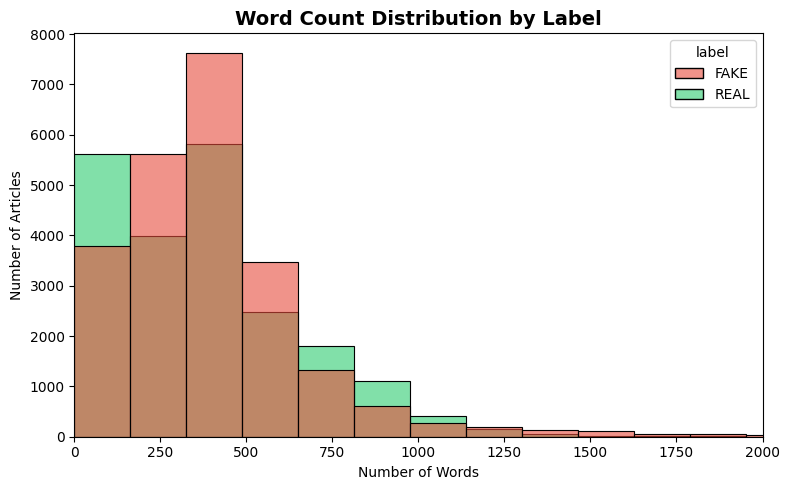

In [ ]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

print("Word count statistics:")
print(df.groupby("label")["word_count"].describe().round(0))

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="word_count", hue="label", bins=50,
             palette=["#E74C3C", "#2ECC71"], alpha=0.6)
plt.title("Word Count Distribution by Label", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

Subjects in FAKE articles:
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

Subjects in REAL articles:
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


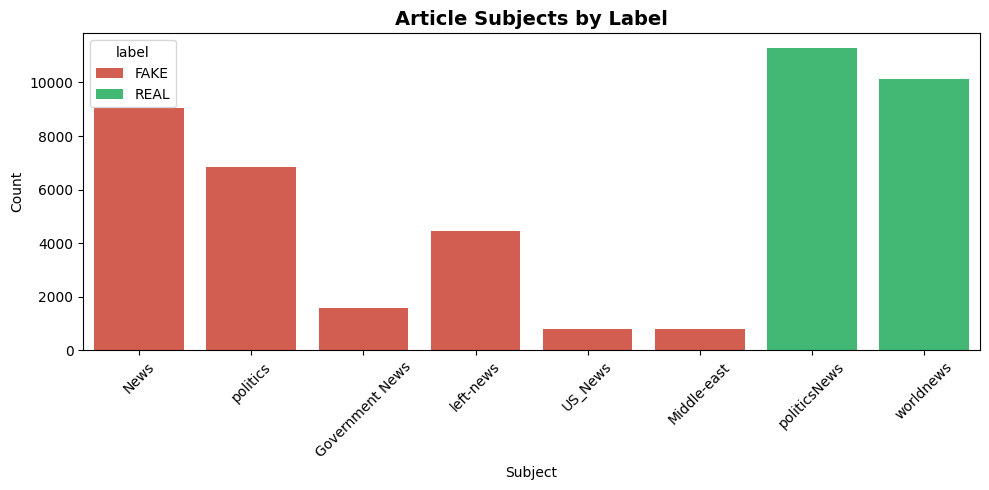

In [ ]:
print("Subjects in FAKE articles:")
print(df[df["label"] == "FAKE"]["subject"].value_counts())

print("\nSubjects in REAL articles:")
print(df[df["label"] == "REAL"]["subject"].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(x="subject", hue="label", data=df,
              palette=["#E74C3C", "#2ECC71"])
plt.title("Article Subjects by Label", fontsize=14, fontweight="bold")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("=== FAKE ARTICLE EXAMPLE ===")
print(df[df["label"] == "FAKE"]["text"].iloc[0][:500])

print("\n=== REAL ARTICLE EXAMPLE ===")
print(df[df["label"] == "REAL"]["text"].iloc[0][:500])

=== FAKE ARTICLE EXAMPLE ===
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a gr

=== REAL ARTICLE EXAMPLE ===
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmake

In [ ]:
print("=" * 50)
print("EDA SUMMARY — DATASET 1: FAKE VS REAL NEWS")
print("=" * 50)
print(f"Total articles:        {len(df):,}")
print(f"Fake articles:         {len(df[df['label'] == 'FAKE']):,}")
print(f"Real articles:         {len(df[df['label'] == 'REAL']):,}")
print(f"Missing values:        {df.isnull().sum().sum()}")
print(f"Columns available:     {df.columns.tolist()}")
print(f"Avg words (Fake):      {df[df['label'] == 'FAKE']['word_count'].mean():.0f}")
print(f"Avg words (Real):      {df[df['label'] == 'REAL']['word_count'].mean():.0f}")
print("=" * 50)

EDA SUMMARY — DATASET 1: FAKE VS REAL NEWS
Total articles:        44,898
Fake articles:         23,481
Real articles:         21,417
Missing values:        0
Columns available:     ['title', 'text', 'subject', 'date', 'label', 'text_length', 'word_count']
Avg words (Fake):      423
Avg words (Real):      386


In [ ]:
# Check for duplicate rows
print("Duplicate rows in full dataset:")
print(df.duplicated().sum())

# Check duplicates based on article text only
print("\nDuplicate articles based on text column only:")
print(df.duplicated(subset=["text"]).sum())

# Show examples of duplicates if any exist
duplicates = df[df.duplicated(subset=["text"], keep=False)]
print(f"\nTotal rows involved in duplicates: {len(duplicates)}")
if len(duplicates) > 0:
    print("\nSample duplicate articles:")
    print(duplicates[["title", "label"]].head(10))

Duplicate rows in full dataset:
209

Duplicate articles based on text column only:
6252

Total rows involved in duplicates: 11392

Sample duplicate articles:
                                                  title label
9087  BARBRA STREISAND Gives Up On Dream Of Impeachi...  FAKE
9088  WATCH: SENATOR LINDSEY GRAHAM DROPS BOMBSHELL…...  FAKE
9089  “CONSERVATIVE GAY GUY” BLASTS Pence’s Aspen Ne...  FAKE
9091  BILL NYE The FAKE Science Guy THREATENS Conser...  FAKE
9093  EMBARRASSING: Anti-Trump “THE HILL” Gets SLAMM...  FAKE
9095  IT ONLY TOOK ONE TWEET FROM PRESIDENT TRUMP Fo...  FAKE
9096  WATCH HERO Singlehandedly Shut Down Anti-Trump...  FAKE
9097  FINALLY RELEASED! Email from Huma Abedin Inclu...  FAKE
9106  CNN’S FAKE NEWS BACKFIRES! CNN Legal Analyst A...  FAKE
9107  WHY THIS Democrat Stronghold County Voted For ...  FAKE


In [ ]:
# Remove duplicates based on text column - keep first occurrence
df = df.drop_duplicates(subset=["text"], keep="first")

# Confirm how many articles remain
print(f"Articles before removing duplicates: 44,898")
print(f"Articles after removing duplicates:  {len(df)}")
print(f"Duplicate articles removed:          {44898 - len(df)}")

# Check label distribution after removing duplicates
print("\nLabel distribution after cleaning:")
print(df["label"].value_counts())

Articles before removing duplicates: 44,898
Articles after removing duplicates:  38646
Duplicate articles removed:          6252

Label distribution after cleaning:
label
REAL    21191
FAKE    17455
Name: count, dtype: int64


In [ ]:
# Remove duplicates
df = df.drop_duplicates(subset=["text"], keep="first")

# Save cleaned dataframe
df.to_csv("/content/drive/MyDrive/FactLens_Group9/data/df_clean.csv", index=False)
print("Saved successfully")
print(f"Total articles saved: {len(df)}")

Saved successfully
Total articles saved: 38646
